In [3]:
import pandas as pd
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import degree

# Configuration 
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Initial Data Loading

In [4]:
# File Paths 
DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw")

# Ensure the processed directory exists
DATA_PROCESSED.mkdir(exist_ok=True)


In [5]:
# Load Data 
paysim_csv_path = DATA_RAW / "online_payments.csv" 
print(f"Loading data from: {paysim_csv_path}")

df = pd.read_csv(paysim_csv_path)

print(f"Initial dataset shape: {df.shape}")
print("A snapshot of the data:")
df.head()

Loading data from: ..\data\raw\online_payments.csv
Initial dataset shape: (6362620, 11)
A snapshot of the data:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. Class-Balanced Downsampling Strategy

In [6]:
# Step 1: Separate classes 
df_fraud = df[df['isFraud'] == 1]
df_legit = df[df['isFraud'] == 0]

print(f"Original transaction counts:")
print(f"  - Legitimate: {len(df_legit):,}")
print(f"  - Fraudulent: {len(df_fraud):,}")
print(f"Original fraud ratio: {len(df_fraud) / len(df):.4%}")

Original transaction counts:
  - Legitimate: 6,354,407
  - Fraudulent: 8,213
Original fraud ratio: 0.1291%


In [7]:
# Step 2: Define sampling ratio
SAMPLING_RATIO = 0.05
df_legit_sampled = df_legit.sample(frac=SAMPLING_RATIO, random_state=42)

In [8]:
#  Step 3: Combine and shuffle 
df_sampled = pd.concat([df_fraud, df_legit_sampled])
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n After Downsampling ")
print(f"New dataset shape: {df_sampled.shape}")
print(f"New transaction counts:")
print(f"  - Legitimate: {len(df_legit_sampled):,}")
print(f"  - Fraudulent: {len(df_fraud):,}")
print(f"New fraud ratio: {len(df_fraud) / len(df_sampled):.2%}")


 After Downsampling 
New dataset shape: (325933, 11)
New transaction counts:
  - Legitimate: 317,720
  - Fraudulent: 8,213
New fraud ratio: 2.52%


## 3. ID Mapping: From Account IDs to Node Indices

In [9]:
# Step 1: Extract all unique accounts 
all_accounts = pd.unique(df_sampled[['nameOrig', 'nameDest']].values.ravel('K'))
num_nodes = len(all_accounts)

print(f"Total unique accounts (nodes) in the graph: {num_nodes:,}")

Total unique accounts (nodes) in the graph: 592,288


In [11]:
# Step 2: Create the mapping dictionary 
account_map = {name: i for i, name in enumerate(all_accounts)}

print("\nExample mapping:")
for i, (name, idx) in enumerate(account_map.items()):
    if i >= 5: break
    print(f'   "{name}" - {idx}')


Example mapping:
   "C1611144363" - 0
   "C1409142151" - 1
   "C194892485" - 2
   "C1873000881" - 3
   "C55146780" - 4


## 4. Constructing the Edge Index

In [12]:
# Step 1: Map sender and receiver columns to integer indices 
src_indices = df_sampled['nameOrig'].map(account_map).values
dst_indices = df_sampled['nameDest'].map(account_map).values

In [13]:
# Step 2: Create the edge_index tensor 
edge_index = torch.tensor([src_indices, dst_indices], dtype=torch.long)

print(f"Successfully created the edge_index tensor.")
print(f"Shape of edge_index: {edge_index.shape}")
print("\nFirst 5 edges (source -> destination):")
print(edge_index[:, :5])

Successfully created the edge_index tensor.
Shape of edge_index: torch.Size([2, 325933])

First 5 edges (source -> destination):
tensor([[     0,      1,      2,      3,      4],
        [325907, 325908, 325909, 325910, 325911]])


## 5. Initial Structural Validation

In [14]:
#  1. Degree Distribution 
out_degrees = degree(edge_index[0], num_nodes=num_nodes)
in_degrees = degree(edge_index[1], num_nodes=num_nodes)

print(f"Average Out-Degree: {out_degrees.float().mean():.2f}")
print(f"Average In-Degree:  {in_degrees.float().mean():.2f}")
print(f"Max Out-Degree:     {out_degrees.max().item()}")
print(f"Max In-Degree:      {in_degrees.max().item()}")

Average Out-Degree: 0.55
Average In-Degree:  0.55
Max Out-Degree:     2.0
Max In-Degree:      9.0


In [15]:
#  2. Connectivity Check 
total_degrees = out_degrees + in_degrees
isolated_nodes = (total_degrees == 0).sum().item()
percentage_isolated = (isolated_nodes / num_nodes) * 100

print(f"\nNumber of isolated nodes: {isolated_nodes} ({percentage_isolated:.2f}%)")


Number of isolated nodes: 0 (0.00%)


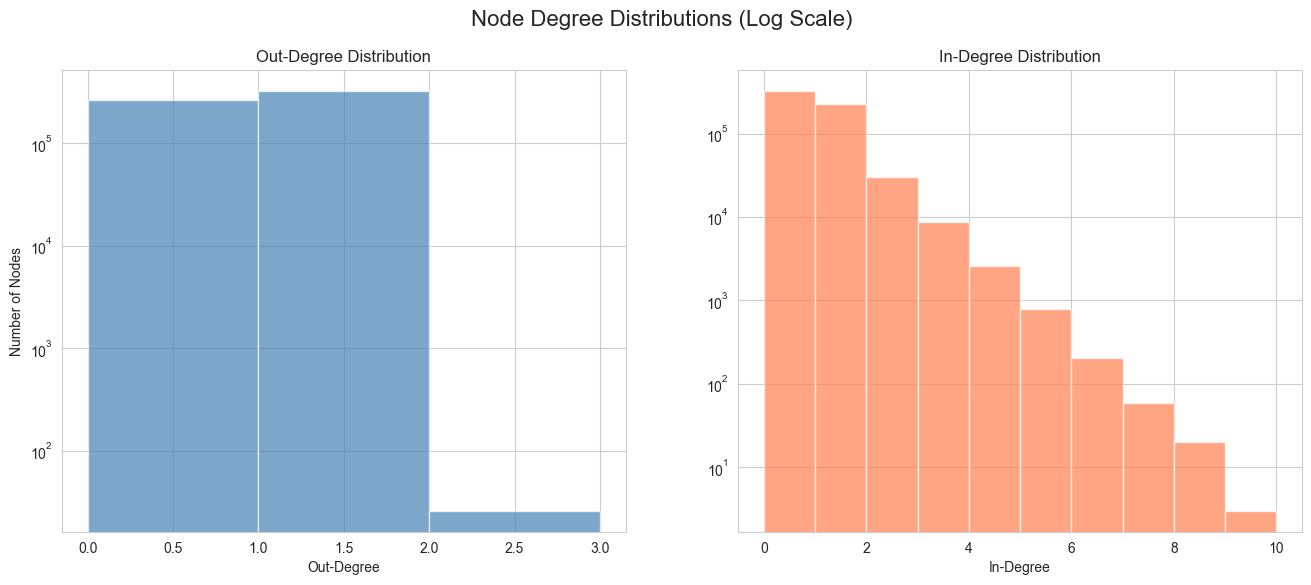

In [16]:
#  3. Visualize Degree Distribution 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(out_degrees.numpy(), bins=range(0, int(out_degrees.max().item()) + 2), alpha=0.7, color='steelblue')
axes[0].set_title('Out-Degree Distribution')
axes[0].set_xlabel('Out-Degree')
axes[0].set_ylabel('Number of Nodes')
axes[0].set_yscale('log')

axes[1].hist(in_degrees.numpy(), bins=range(0, int(in_degrees.max().item()) + 2), alpha=0.7, color='coral')
axes[1].set_title('In-Degree Distribution')
axes[1].set_xlabel('In-Degree')
axes[1].set_yscale('log')

plt.suptitle('Node Degree Distributions (Log Scale)', fontsize=16)
plt.show()

## 6. Saving the Graph Structure

In [17]:
graph_structure_data = {
    'df_sampled': df_sampled,
    'account_map': account_map,
    'num_nodes': num_nodes,
    'edge_index': edge_index,
}

save_path = DATA_PROCESSED / "paysim_graph_structure.pt"
torch.save(graph_structure_data, save_path)

print(f"Graph structural data saved successfully to:")
print(save_path)

Graph structural data saved successfully to:
..\data\processed\paysim_graph_structure.pt
